## Let's understand `torch.backward()` known as back propagation easy way first

In [9]:
import torch
# we will create two rank 1 tensor (scalar) with requires_grad attribute true to tell pytorch we need gradient
a = torch.tensor([2.0], requires_grad=True)
b = torch.tensor([3.0],requires_grad=True)

# Forward propagation: it is the process which focuses on getting best output
c = a * b # c is 6.0
# Backward propagation: it is the process of calculating gradient of earlier tensors to determine how much each of those earlier tensors affect the final outcome.
c.backward()
# check the blame/gradient/rate of affecting
print(f"how much 'a' affected 'c': {a.grad}")
print(f"how much 'b' affected 'c': {b.grad}")


how much 'a' affected 'c': tensor([3.])
how much 'b' affected 'c': tensor([2.])


### let's explain how?
![Autograd explanation for c=a*b](./autograd_c.png)

We can see our gradient of a is 3 and gradient of b is 2. When we call `c.backward()` pytorch starts at the end with a gradient of 1.0 always which will be for c. Our gradient function to get c is stored as `grad_fn=MulBackward` that `MulBackward` function consists of `AccumulateGrad` function for tensor `a` and `b` which calculates the gradient. Gradients are simply calculated using `derivatives` of calculus. But for simple understanding, we can say:

`c = 6, a = 2 and b = 3`

Rule is simple:

How many a contributes to be $c = 3a$. Therefore gradient of a will be: `a.grad = 1.0 * 3.0`

Similarly, 2 times b contributes to be $c = 2b$. Therefore, gradient of b will be: `b.grad = 1.0 * 2.0`

## Let's try another example:
_Note: if we try to do `e.backward` then we will get runtime error because we already did `c.backward`. Therefore once we do backward, pytorch runs backward and then clears the map how backward was calculated that memory thinking we already did what we need and we don't need anymore. Hence to get gradient of `a` and `b`, we need to do the same math again. But the problem is although, it can't calculate the backward unless we redo, but it does remembers the previous gradient value of each variable and will accumulate over if we redo therefore, we have to flush previously calculated gradient for each._

In [10]:

if a.grad is not None:
    a.grad = None
if b.grad is not None:
    b.grad = None

# Forward Propagation
c = a * b
d = torch.tensor([4.0],requires_grad=True)
e = c + d
# Backward Propagation
e.backward()
# check the gradient
print(f"how much 'd' affected 'e': {d.grad}")
print(f"how much 'c' affected 'e': {c.grad}")
# gradient of a and b shouldn't change because the gradient of c would be 1.0 as addition affects the outcome by 1 times only
print(f"how much 'a' affected 'c': {a.grad}")
print(f"how much 'b' affected 'c': {b.grad}")

how much 'd' affected 'e': tensor([1.])
how much 'c' affected 'e': None
how much 'a' affected 'c': tensor([3.])
how much 'b' affected 'c': tensor([2.])


C:\Users\sauga\AppData\Local\Temp\ipykernel_9692\3563079876.py:14: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\build\aten\src\ATen/core/TensorBody.h:494.)
  print(f"how much 'c' affected 'e': {c.grad}")


This is the perfect example to see the "Telephone Game" (Chain Rule) in action. Let's trace it exactly how PyTorch’s autograd engine does it.
1. **The Forward Pass (The Values)**

First, we calculate the actual numbers:

- $a = 2, b = 3 \rightarrow \mathbf{c = 6}$
- $d = 4$
- $\mathbf{e = 10}$ ($6 + 4$)

2. **The Backward Pass (The "Sensitivity Scores")**

When we call e.backward(), PyTorch starts at the end with a gradient of 1.0 for $e$. Now it moves backward step-by-step.

**Step 1: From $e$ to $c$ and $d$ (Addition Rule)**

The operation was $e = c + d$.

- The Rule for Addition: The "sensitivity" is always 1. (If you increase $c$ by 1, $e$ increases by 1).
- The Math: $1.0$ (from $e$) $\times$ $1$ (the rule).
- Result: d.grad = 1.0 and c.grad = 1.0.

**Step 2: From $c$ back to $a$ and $b$ (Multiplication Rule)**

The operation was $c = a \times b$.
- The Rule for Multiplication: The "sensitivity" of one variable is the value of the other.
- The Math for $a$: Take $c$'s gradient ($1.0$) and multiply it by the value of $b$ ($3$).a.grad = 1.0 * 3 = 3.0
- The Math for $b$: Take $c$'s gradient ($1.0$) and multiply it by the value of $a$ ($2$).b.grad = 1.0 * 2 = 2.0

3. **Final Gradients (The "Blame" List)**
Here is what is stored in the .grad attributes after the math is done:

| Variable | Gradient | What it means in plain English |
|----------|----------|--------------------------------|
| $e$| 1.0 | $e$ is 100% sensitive to itself. |
| $d | $1.0 | If you increase $d$ by 0.1, $e$ goes up by 0.1. | 
| $c$ | 1.0 | If you increase $c$ by 0.1, $e$ goes up by 0.1. |
| $b$ | 2.0 | If you increase $b$ by 0.1, $e$ goes up by 0.2 (because $b$ is multiplied by $a=2$). |
| $a$ | 3.0 | If you increase $a$ by 0.1, $e$ goes up by 0.3 (because $a$ is multiplied by $b=3$). | 

**Why $a$ has a higher gradient than $b$?**

Because $a$ is being multiplied by a bigger number ($b=3$). In the eyes of the "Final Result" ($e$), changing $a$ is "riskier" or "more powerful" than changing $b$ at this specific moment.If this were a neural network, the optimizer would look at $a$ and say: "Wow, $a$ has a gradient of 3.0! That's a high sensitivity score. I need to adjust $a$ more than I adjust $b$ to fix the error."

**What is conclusion?**

Because $a$ has a higher gradient (3.0), it is the most "powerful" lever you have to change the final result $e$.

To answer whether we increase or decrease it, it depends entirely on your goal. 

In AI, we usually have two scenarios:

**Scenario A: You want to DECREASE the outcome (Minimizing Loss)**

If $e$ represents your "Error" or "Loss," you want it to go down.

- The Rule: Since the gradient of $a$ is positive (+3.0), it means $a$ and $e$ move in the same direction. If $a$ goes up, $e$ goes up.
- The Action: To make $e$ smaller, you must decrease $a$.
- The Scale: Because $a$'s gradient is 3.0 and $b$'s is 2.0, you would decrease $a$ more than you decrease $b$ to get the fastest drop in error.

**Scenario B: You want to INCREASE the outcome (Maximizing a Score)**

If $e$ is a "Reward" or "Accuracy Score," you want it to go up.
- The Rule: Since the gradient is positive, they move together.
- The Action: You increase $a$.
- The Scale: Again, increasing $a$ by 1 unit gives you a bigger "boost" (+3) than increasing $b$ by 1 unit (+2).

### Let's say in case if we had multiplication instead of addition i.e. $e = c * d$
![autograd explanation for e = c*d](./autograd_e.png)

### _Note: Autograd uses derivatives of calculus to calculate the gradient during .backward but for easiness of understanding we are doing this way but this isn't the actual way to calculate gradient._

In [11]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

A Gentle Introduction to `torch.autograd`
=========================================

`torch.autograd` is PyTorch's automatic differentiation engine that
powers neural network training. In this section, you will get a
conceptual understanding of how autograd helps a neural network train.

Background
----------

Neural networks (NNs) are a collection of nested functions that are
executed on some input data. These functions are defined by *parameters*
(consisting of weights and biases), which in PyTorch are stored in
tensors.

Training a NN happens in two steps:

**Forward Propagation**: In forward prop, the NN makes its best guess
about the correct output. It runs the input data through each of its
functions to make this guess.

**Backward Propagation**: In backprop, the NN adjusts its parameters
proportionate to the error in its guess. It does this by traversing
backwards from the output, collecting the derivatives of the error with
respect to the parameters of the functions (*gradients*), and optimizing
the parameters using gradient descent. For a more detailed walkthrough
of backprop, check out this [video from
3Blue1Brown](https://www.youtube.com/watch?v=tIeHLnjs5U8).

Usage in PyTorch
----------------

Let\'s take a look at a single training step. For this example, we load
a pretrained resnet18 model from `torchvision`. We create a random data
tensor to represent a single image with 3 channels, and height & width
of 64, and its corresponding `label` initialized to some random values.
Label in pretrained models has shape (1,1000).

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>This tutorial works only on the CPU and will not work on GPU devices (even if tensors are moved to CUDA).</p>

</div>



In [12]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64)
labels = torch.rand(1, 1000)

_Note:`data = torch.rand(1,3,64,64)` is passing completely random numbers in the matrix between 0 and 1 which doesn't represents any kind of image. For example we can see below. Similarly, labels are also 1000 random numbers in between 0 and 1 which doesn't represent any thing in particular._
### Image will cause error so, we need to fix it:

The Shape Conflict
- PyTorch: It stores images as (Batch, Channels, Height, Width). For your data, that is (1, 3, 64, 64).
- Matplotlib: It expects images as (Height, Width, Channels). It wants (64, 64, 3).

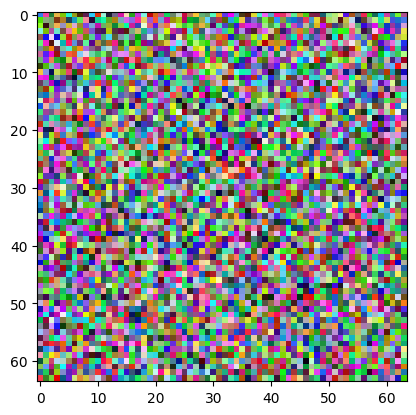

In [13]:
import matplotlib.pyplot as plt
# 1. Remove the batch dimension (the '1')
img = data.squeeze(0) # Shape becomes (3, 64, 64)

# 2. Rearrange the dimensions from (3, 64, 64) to (64, 64, 3)
img = img.permute(1, 2, 0) 

# 3. Show it!
plt.imshow(img)
plt.show()

Next, we run the input data through the model through each of its layers
to make a prediction. This is the **forward pass**.


In [14]:
prediction = model(data) # forward pass

_Note: Model will spit out matrix containing probabilities for each 1000 labels which we can use to calculate the loss._

We use the model\'s prediction and the corresponding label to calculate
the error (`loss`). The next step is to backpropagate this error through
the network. Backward propagation is kicked off when we call
`.backward()` on the error tensor. Autograd then calculates and stores
the gradients for each model parameter in the parameter\'s `.grad`
attribute.


In [15]:
loss = (prediction - labels).sum()
loss.backward() # backward pass

_Note: When we call `.backward()`, it will calculate gradient for all the weights associated with model and will store those gradients into the respective tensor for optimization._

Next, we load an optimizer, in this case SGD with a learning rate of
0.01 and
[momentum](https://medium.com/data-science/stochastic-gradient-descent-with-momentum-a84097641a5d)
of 0.9. We register all the parameters of the model in the optimizer.


In [16]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

_Note: We are setting SGD 'Stochastic Gradient Descent' method for optimization to nudge different weights according to previously calculated gradient of each tensor to improve the model._

Finally, we call `.step()` to initiate gradient descent. The optimizer
adjusts each parameter by its gradient stored in `.grad`.


In [17]:
optim.step() #gradient descent

_Note:`optim.step()` will finally nudge all the weights based on previously calculated gradients to make model more accurate._

At this point, you have everything you need to train your neural
network. The below sections detail the workings of autograd - feel free
to skip them.


------------------------------------
Note: We are done with this notebook and I am not going further below than this because I have already understood and explained the same principle of calculating gradient in easy way.

------------------------------------------------------------------------


Differentiation in Autograd
===========================

Let\'s take a look at how `autograd` collects gradients. We create two
tensors `a` and `b` with `requires_grad=True`. This signals to
`autograd` that every operation on them should be tracked.


In [18]:
import torch

a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

We create another tensor `Q` from `a` and `b`.

$$Q = 3a^3 - b^2$$


In [19]:
Q = 3*a**3 - b**2

Let\'s assume `a` and `b` to be parameters of an NN, and `Q` to be the
error. In NN training, we want gradients of the error w.r.t. parameters,
i.e.

$$\frac{\partial Q}{\partial a} = 9a^2$$

$$\frac{\partial Q}{\partial b} = -2b$$

When we call `.backward()` on `Q`, autograd calculates these gradients
and stores them in the respective tensors\' `.grad` attribute.

We need to explicitly pass a `gradient` argument in `Q.backward()`
because it is a vector. `gradient` is a tensor of the same shape as `Q`,
and it represents the gradient of Q w.r.t. itself, i.e.

$$\frac{dQ}{dQ} = 1$$

Equivalently, we can also aggregate Q into a scalar and call backward
implicitly, like `Q.sum().backward()`.


In [20]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

Gradients are now deposited in `a.grad` and `b.grad`


In [21]:
# check if collected gradients are correct
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


Optional Reading - Vector Calculus using `autograd`
===================================================

Mathematically, if you have a vector valued function
$\vec{y}=f(\vec{x})$, then the gradient of $\vec{y}$ with respect to
$\vec{x}$ is a Jacobian matrix $J$:

$$\begin{aligned}
J
=
 \left(\begin{array}{cc}
 \frac{\partial \bf{y}}{\partial x_{1}} &
 ... &
 \frac{\partial \bf{y}}{\partial x_{n}}
 \end{array}\right)
=
\left(\begin{array}{ccc}
 \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{1}}{\partial x_{n}}\\
 \vdots & \ddots & \vdots\\
 \frac{\partial y_{m}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
 \end{array}\right)
\end{aligned}$$

Generally speaking, `torch.autograd` is an engine for computing
vector-Jacobian product. That is, given any vector $\vec{v}$, compute
the product $J^{T}\cdot \vec{v}$

If $\vec{v}$ happens to be the gradient of a scalar function
$l=g\left(\vec{y}\right)$:

$$\vec{v}
 =
 \left(\begin{array}{ccc}\frac{\partial l}{\partial y_{1}} & \cdots & \frac{\partial l}{\partial y_{m}}\end{array}\right)^{T}$$

then by the chain rule, the vector-Jacobian product would be the
gradient of $l$ with respect to $\vec{x}$:

$$\begin{aligned}
J^{T}\cdot \vec{v} = \left(\begin{array}{ccc}
 \frac{\partial y_{1}}{\partial x_{1}} & \cdots & \frac{\partial y_{m}}{\partial x_{1}}\\
 \vdots & \ddots & \vdots\\
 \frac{\partial y_{1}}{\partial x_{n}} & \cdots & \frac{\partial y_{m}}{\partial x_{n}}
 \end{array}\right)\left(\begin{array}{c}
 \frac{\partial l}{\partial y_{1}}\\
 \vdots\\
 \frac{\partial l}{\partial y_{m}}
 \end{array}\right) = \left(\begin{array}{c}
 \frac{\partial l}{\partial x_{1}}\\
 \vdots\\
 \frac{\partial l}{\partial x_{n}}
 \end{array}\right)
\end{aligned}$$

This characteristic of vector-Jacobian product is what we use in the
above example; `external_grad` represents $\vec{v}$.


Computational Graph
===================

Conceptually, autograd keeps a record of data (tensors) & all executed
operations (along with the resulting new tensors) in a directed acyclic
graph (DAG) consisting of
[Function](https://pytorch.org/docs/stable/autograd.html#torch.autograd.Function)
objects. In this DAG, leaves are the input tensors, roots are the output
tensors. By tracing this graph from roots to leaves, you can
automatically compute the gradients using the chain rule.

In a forward pass, autograd does two things simultaneously:

-   run the requested operation to compute a resulting tensor, and
-   maintain the operation's *gradient function* in the DAG.

The backward pass kicks off when `.backward()` is called on the DAG
root. `autograd` then:

-   computes the gradients from each `.grad_fn`,
-   accumulates them in the respective tensor's `.grad` attribute, and
-   using the chain rule, propagates all the way to the leaf tensors.

Below is a visual representation of the DAG in our example. In the
graph, the arrows are in the direction of the forward pass. The nodes
represent the backward functions of each operation in the forward pass.
The leaf nodes in blue represent our leaf tensors `a` and `b`.

![](https://pytorch.org/tutorials/_static/img/dag_autograd.png)

<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>An important thing to note is that the graph is recreated from scratch; after each<code>.backward()</code> call, autograd starts populating a new graph. This isexactly what allows you to use control flow statements in your model;you can change the shape, size and operations at every iteration ifneeded.</p>

</div>

Exclusion from the DAG
----------------------

`torch.autograd` tracks operations on all tensors which have their
`requires_grad` flag set to `True`. For tensors that don't require
gradients, setting this attribute to `False` excludes it from the
gradient computation DAG.

The output tensor of an operation will require gradients even if only a
single input tensor has `requires_grad=True`.


In [22]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f"Does `a` require gradients?: {a.requires_grad}")
b = x + z
print(f"Does `b` require gradients?: {b.requires_grad}")

Does `a` require gradients?: False
Does `b` require gradients?: True


In a NN, parameters that don\'t compute gradients are usually called
**frozen parameters**. It is useful to \"freeze\" part of your model if
you know in advance that you won\'t need the gradients of those
parameters (this offers some performance benefits by reducing autograd
computations).

In finetuning, we freeze most of the model and typically only modify the
classifier layers to make predictions on new labels. Let\'s walk through
a small example to demonstrate this. As before, we load a pretrained
resnet18 model, and freeze all the parameters.


In [23]:
from torch import nn, optim

model = resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all the parameters in the network
for param in model.parameters():
    param.requires_grad = False

Let\'s say we want to finetune the model on a new dataset with 10
labels. In resnet, the classifier is the last linear layer `model.fc`.
We can simply replace it with a new linear layer (unfrozen by default)
that acts as our classifier.


In [24]:
model.fc = nn.Linear(512, 10)

Now all parameters in the model, except the parameters of `model.fc`,
are frozen. The only parameters that compute gradients are the weights
and bias of `model.fc`.


In [25]:
# Optimize only the classifier
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

Notice although we register all the parameters in the optimizer, the
only parameters that are computing gradients (and hence updated in
gradient descent) are the weights and bias of the classifier.

The same exclusionary functionality is available as a context manager in
[torch.no\_grad()](https://pytorch.org/docs/stable/generated/torch.no_grad.html)


------------------------------------------------------------------------


Further readings:
=================

-   [In-place operations & Multithreaded
    Autograd](https://pytorch.org/docs/stable/notes/autograd.html)
-   [Example implementation of reverse-mode
    autodiff](https://colab.research.google.com/drive/1VpeE6UvEPRz9HmsHh1KS0XxXjYu533EC)
-   [Video: PyTorch Autograd Explained - In-depth
    Tutorial](https://www.youtube.com/watch?v=MswxJw-8PvE)
